# PZT physics-feature MLP: baseline vs magnet

This is a **meeting proof of concept**.

- Input: `X_pzt_baseline` or `X_pzt_damage`
- Output: path-level probability of the magnet state
- Ground truth: 0 for `test_avg64`, 1 for `damage_avg64`
- Split: reciprocal PZT pairs are held out together
- Models: small MLP and logistic-regression baseline

The experiment contains one specimen and one magnet position, so it does not demonstrate generalization to unseen damage.

In [1]:
from pathlib import Path
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import GroupKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import balanced_accuracy_score, accuracy_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression

PROJECT_DIR=Path.cwd()
if str(PROJECT_DIR) not in sys.path: sys.path.insert(0,str(PROJECT_DIR))
from dl_settings import *
from dl_utils import *

set_seed(RANDOM_SEED)
device=choose_device(DEVICE)
PZT_DIR=DATASET_ROOT/PZT_FOLDER
RESULTS_ROOT=ensure_dir(PROJECT_DIR/RESULTS_FOLDER)
FIG_DIR=ensure_dir(PROJECT_DIR/"figures")
OUT=ensure_dir(RESULTS_ROOT/"10_pzt_mlp_classifier")
feature_path=find_feature_file(PZT_DIR,FEATURE_FILE_CANDIDATES)
print("Feature file:",feature_path)
print("Device:",device)
print("Results folder:",OUT)
print("Figures folder:",FIG_DIR)

Feature file: /home/awais/Desktop/Awais Work 2026/KAIST Work/Team 1/KAIST Data/20260611_Data2/260609_pzt_network/physics_features_phase1_bpf.npz
Device: cuda
Results folder: /home/awais/Desktop/Awais Work 2026/KAIST Work/Team 1/KAIST Data/20260611_Data2/AwsGPT_Codes/July2_DL_Meeting_work/paper5_dl_results/10_pzt_mlp_classifier
Figures folder: /home/awais/Desktop/Awais Work 2026/KAIST Work/Team 1/KAIST Data/20260611_Data2/AwsGPT_Codes/July2_DL_Meeting_work/figures


In [2]:
with np.load(feature_path,allow_pickle=False) as z:
    print("Keys:",z.files)
    pair_idx=normalize_pair_idx(z["pair_idx"])
    Xb_raw=z["X_pzt_baseline"]
    Xd_raw=z["X_pzt_damage"]

n_paths=len(pair_idx)
Xb=flatten_samples(to_sample_first(Xb_raw,n_paths))
Xd=flatten_samples(to_sample_first(Xd_raw,n_paths))

X=np.concatenate([Xb,Xd],axis=0)
y=np.concatenate([np.zeros(n_paths,dtype=int),np.ones(n_paths,dtype=int)])
pair_idx_all=np.concatenate([pair_idx,pair_idx],axis=0)
g0=reciprocal_group_ids(pair_idx)
groups=np.concatenate([g0,g0],axis=0)

feature_names=[f"feature_{i:02d}" for i in range(X.shape[1])]

print("X:",X.shape," y:",np.bincount(y)," groups:",len(np.unique(groups)))
input_summary=pd.DataFrame([
    {"network_input":"baseline rows","source":"X_pzt_baseline","raw_shape":Xb_raw.shape,"network_shape":Xb.shape,"nan_count":int(np.isnan(Xb).sum()),"inf_count":int(np.isinf(Xb).sum())},
    {"network_input":"magnet rows","source":"X_pzt_damage","raw_shape":Xd_raw.shape,"network_shape":Xd.shape,"nan_count":int(np.isnan(Xd).sum()),"inf_count":int(np.isinf(Xd).sum())},
    {"network_input":"combined MLP input","source":"concatenate baseline+magnet","raw_shape":"","network_shape":X.shape,"nan_count":int(np.isnan(X).sum()),"inf_count":int(np.isinf(X).sum())},
])
display(input_summary)
input_preview=pd.DataFrame(X[:8],columns=feature_names)
input_preview.insert(0,"state",np.where(y[:8]==0,"baseline","magnet"))
input_preview.insert(0,"rx",pair_idx_all[:8,1])
input_preview.insert(0,"src",pair_idx_all[:8,0])
print("Raw physics features before fold-local imputation and scaling:")
display(input_preview)

Keys: ['X_pzt_baseline', 'X_pzt_damage', 'X_ldv_virtual', 'X_ldv_2d', 'X_ldv_extra2d', 'X_ldv_full', 'pair_idx', 'freqs_kHz']
X: (60, 10)  y: [30 30]  groups: 15


,network_input,source,raw_shape,network_shape,nan_count,inf_count
0,baseline rows,X_pzt_baseline,"(30, 10)","(30, 10)",90,0
1,magnet rows,X_pzt_damage,"(30, 10)","(30, 10)",0,0
2,combined MLP input,concatenate baseline+magnet,,"(60, 10)",90,0


Raw physics features before fold-local imputation and scaling:


,src,rx,state,feature_00,feature_01,feature_02,feature_03,feature_04,feature_05,feature_06,feature_07,feature_08,feature_09
0,1,2,baseline,70.454544,86.818184,656.746094,276.067902,0.016675,115.437073,0.0,NaN,NaN,NaN
1,1,3,baseline,89.545456,423.181824,438.706573,165.548004,0.017190,113.848869,10.0,NaN,NaN,NaN
2,1,4,baseline,101.363640,372.272736,787.595398,246.333786,0.016692,98.897171,30.0,NaN,NaN,NaN
3,1,5,baseline,87.727272,102.727272,462.491150,186.579010,0.000172,102.310104,40.0,NaN,NaN,NaN
4,1,6,baseline,70.000000,86.363640,545.706116,208.825195,0.006977,108.717819,20.0,NaN,NaN,NaN
5,2,1,baseline,70.454544,90.000000,601.652039,252.637558,0.017619,115.239349,0.0,NaN,NaN,NaN
6,2,3,baseline,71.363640,115.000000,751.157227,304.930756,0.000790,104.010864,10.0,NaN,NaN,NaN
7,2,4,baseline,87.727272,246.818176,426.162201,171.090256,0.000401,107.651199,20.0,NaN,NaN,NaN


In [3]:
class SmallMLP(nn.Module):
    def __init__(self,input_dim):
        super().__init__()
        h1=min(128,max(32,input_dim//2))
        h2=min(64,max(16,h1//2))
        self.net=nn.Sequential(
            nn.Linear(input_dim,h1),nn.ReLU(),nn.Dropout(.20),
            nn.Linear(h1,h2),nn.ReLU(),nn.Dropout(.15),
            nn.Linear(h2,1)
        )
    def forward(self,x): return self.net(x).squeeze(-1)

def train_model(Xtr,ytr,Xv,yv,seed):
    set_seed(seed)
    model=SmallMLP(Xtr.shape[1]).to(device)
    opt=torch.optim.AdamW(model.parameters(),lr=1e-3,weight_decay=1e-4)
    loss_fn=nn.BCEWithLogitsLoss()
    loader=DataLoader(TensorDataset(torch.tensor(Xtr,dtype=torch.float32),
                                    torch.tensor(ytr,dtype=torch.float32)),
                      batch_size=min(16,len(Xtr)),shuffle=True)
    Xv_t=torch.tensor(Xv,dtype=torch.float32,device=device)
    yv_t=torch.tensor(yv,dtype=torch.float32,device=device)
    best={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
    best_loss=np.inf; wait=0; hist=[]
    for epoch in range(300):
        model.train(); losses=[]
        for xb,yb in loader:
            xb,yb=xb.to(device),yb.to(device)
            xb=xb+0.01*torch.randn_like(xb)
            opt.zero_grad()
            loss=loss_fn(model(xb),yb)
            loss.backward(); opt.step()
            losses.append(loss.item())
        model.eval()
        with torch.no_grad():
            vl=loss_fn(model(Xv_t),yv_t).item()
        hist.append((epoch,float(np.mean(losses)),vl))
        if not np.isfinite(vl):
            wait+=1
            if wait>=30: break
            continue
        if vl<best_loss-1e-5:
            best_loss=vl
            best={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
            wait=0
        else:
            wait+=1
        if wait>=30: break
    model.load_state_dict(best); model.eval()
    return model,pd.DataFrame(hist,columns=["epoch","train_loss","val_loss"])

In [4]:
n_splits=min(5,len(np.unique(groups)))
gkf=GroupKFold(n_splits=n_splits)
oof_mlp=np.full(len(y),np.nan)
oof_lr=np.full(len(y),np.nan)
fold_rows=[]; histories=[]

for fold,(train_idx,test_idx) in enumerate(gkf.split(X,y,groups),1):
    train_groups=np.unique(groups[train_idx])
    val_group=train_groups[-1]
    val_mask=groups[train_idx]==val_group
    fit_idx=train_idx[~val_mask]
    val_idx=train_idx[val_mask]

    imputer=SimpleImputer(strategy="median").fit(X[fit_idx])
    Xfit_raw=imputer.transform(X[fit_idx]); Xval_raw=imputer.transform(X[val_idx]); Xtest_raw=imputer.transform(X[test_idx])
    scaler=StandardScaler().fit(Xfit_raw)
    Xfit=scaler.transform(Xfit_raw); Xval=scaler.transform(Xval_raw); Xtest=scaler.transform(Xtest_raw)
    if fold==1:
        display(pd.DataFrame([
            {"actual_network_input":"Xfit","shape":Xfit.shape,"nan_count":int(np.isnan(Xfit).sum()),"inf_count":int(np.isinf(Xfit).sum())},
            {"actual_network_input":"Xval","shape":Xval.shape,"nan_count":int(np.isnan(Xval).sum()),"inf_count":int(np.isinf(Xval).sum())},
            {"actual_network_input":"Xtest","shape":Xtest.shape,"nan_count":int(np.isnan(Xtest).sum()),"inf_count":int(np.isinf(Xtest).sum())},
        ]))
        network_preview=pd.DataFrame(Xfit[:5],columns=feature_names)
        network_preview.insert(0,"label",y[fit_idx][:5])
        network_preview.insert(0,"row_index",fit_idx[:5])
        print("First fold MLP input after imputation and StandardScaler:")
        display(network_preview)

    model,h=train_model(Xfit,y[fit_idx],Xval,y[val_idx],RANDOM_SEED+fold)
    h["fold"]=fold; histories.append(h)
    with torch.no_grad():
        prob=torch.sigmoid(model(torch.tensor(Xtest,dtype=torch.float32,device=device))).cpu().numpy()
    oof_mlp[test_idx]=prob

    lr=LogisticRegression(max_iter=2000,class_weight="balanced")
    lr.fit(Xfit,y[fit_idx])
    oof_lr[test_idx]=lr.predict_proba(Xtest)[:,1]

    pred=(prob>=.5).astype(int)
    fold_rows.append({
        "fold":fold,
        "balanced_accuracy":balanced_accuracy_score(y[test_idx],pred),
        "f1":f1_score(y[test_idx],pred),
        "auc":roc_auc_score(y[test_idx],prob) if len(np.unique(y[test_idx]))==2 else np.nan
    })

fold_metrics=pd.DataFrame(fold_rows)
display(fold_metrics)
display(fold_metrics.mean(numeric_only=True))
fold_metrics.to_csv(OUT/"fold_metrics.csv",index=False)
pd.concat(histories,ignore_index=True).to_csv(OUT/"training_histories.csv",index=False)

,actual_network_input,shape,nan_count,inf_count
0,Xfit,"(44, 10)",0,0
1,Xval,"(4, 10)",0,0
2,Xtest,"(12, 10)",0,0


First fold MLP input after imputation and StandardScaler:


,row_index,label,feature_00,feature_01,feature_02,feature_03,feature_04,feature_05,feature_06,feature_07,feature_08,feature_09
0,0,0,-1.487810,-0.779434,-0.222832,-0.092981,0.532673,1.382980,-1.113172,-0.141037,-0.210024,-0.156404
1,1,0,0.142957,1.979984,-1.278908,-1.230084,0.580574,1.065626,-0.335718,-0.141037,-0.210024,-0.156404
2,2,0,1.152479,1.562343,0.410938,-0.398905,0.534195,-1.922009,1.219188,-0.141037,-0.210024,-0.156404
3,3,0,-0.012354,-0.648921,-1.163707,-1.013703,-1.002166,-1.240040,1.996641,-0.141037,-0.210024,-0.156404
4,5,0,-1.487810,-0.753331,-0.489680,-0.334048,0.620394,1.343471,-1.113172,-0.141037,-0.210024,-0.156404


,fold,balanced_accuracy,f1,auc
0,1,0.833333,0.833333,0.972222
1,2,1.000000,1.000000,1.000000
2,3,0.583333,0.285714,0.944444
3,4,0.916667,0.923077,1.000000
4,5,0.916667,0.909091,1.000000


fold                 3.000000
balanced_accuracy    0.850000
f1                   0.790243
auc                  0.983333
dtype: float64

,model,accuracy,balanced_accuracy,f1,auc
0,Small MLP,0.850000,0.850000,0.836364,0.971111
1,Logistic regression,0.533333,0.533333,0.461538,0.538889


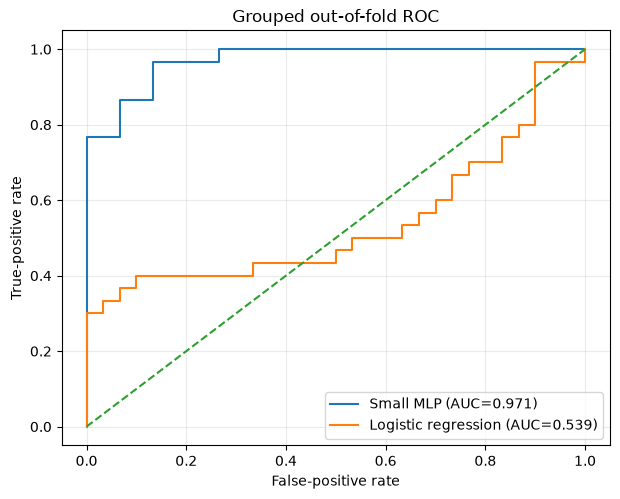

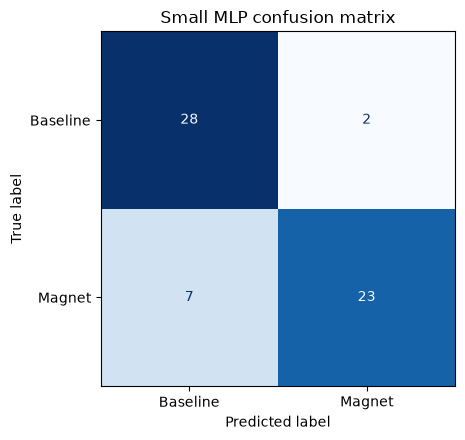

In [5]:
def summary_row(name,prob):
    pred=(prob>=.5).astype(int)
    return {
        "model":name,
        "accuracy":accuracy_score(y,pred),
        "balanced_accuracy":balanced_accuracy_score(y,pred),
        "f1":f1_score(y,pred),
        "auc":roc_auc_score(y,prob)
    }

summary=pd.DataFrame([summary_row("Small MLP",oof_mlp),summary_row("Logistic regression",oof_lr)])
display(summary)
summary.to_csv(OUT/"model_summary.csv",index=False)

fig,ax=plt.subplots(figsize=(6.3,5.1))
for name,prob in [("Small MLP",oof_mlp),("Logistic regression",oof_lr)]:
    fpr,tpr,_=roc_curve(y,prob)
    ax.plot(fpr,tpr,label=f"{name} (AUC={roc_auc_score(y,prob):.3f})")
ax.plot([0,1],[0,1],"--")
ax.set_xlabel("False-positive rate"); ax.set_ylabel("True-positive rate")
ax.set_title("Grouped out-of-fold ROC"); ax.legend(); ax.grid(alpha=.25)
fig.tight_layout(); fig.savefig(FIG_DIR/"10_Figure_DL_ROC.png",dpi=300,bbox_inches="tight"); plt.show()

pred=(oof_mlp>=.5).astype(int)
fig,ax=plt.subplots(figsize=(5,4.5))
ConfusionMatrixDisplay(confusion_matrix(y,pred),display_labels=["Baseline","Magnet"]).plot(ax=ax,cmap="Blues",colorbar=False)
ax.set_title("Small MLP confusion matrix")
fig.tight_layout(); fig.savefig(FIG_DIR/"10_Figure_DL_confusion_matrix.png",dpi=300,bbox_inches="tight"); plt.show()

In [6]:
predictions=pd.DataFrame({
    "src":pair_idx_all[:,0],
    "rx":pair_idx_all[:,1],
    "state":np.where(y==0,"baseline","magnet"),
    "label":y,
    "prob_damage_mlp":oof_mlp,
    "prob_damage_logreg":oof_lr,
    "reciprocal_group":groups
})
display(predictions.head())
predictions.to_csv(OUT/"path_level_oof_predictions.csv",index=False)
print("Saved to:",OUT)

,src,rx,state,label,prob_damage_mlp,prob_damage_logreg,reciprocal_group
0,1,2,baseline,0,0.013335,0.455678,0
1,1,3,baseline,0,0.505353,0.615260,1
2,1,4,baseline,0,0.145168,0.403138,2
3,1,5,baseline,0,0.033934,0.441684,3
4,1,6,baseline,0,0.025377,0.562659,4


Saved to: /home/awais/Desktop/Awais Work 2026/KAIST Work/Team 1/KAIST Data/20260611_Data2/AwsGPT_Codes/July2_DL_Meeting_work/paper5_dl_results/10_pzt_mlp_classifier


## Meeting wording

Use:  
**“A small physics-feature MLP separated the reference and magnet states under reciprocal-pair-held-out cross-validation.”**

Do not say that the model generalizes to unseen damage positions or specimens.